#Exercise: Build a Denoising Convolutional Autoencoder

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

#1. Dataset Preparation and Preprocessing:

In [4]:
dataset_path = "/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset"

train_path = os.path.join(dataset_path, "Train")
test_path = os.path.join(dataset_path, "Test")

print("Train path exists:", os.path.exists(train_path))
print("Test path exists:", os.path.exists(test_path))

Train path exists: True
Test path exists: True


In [6]:
def load_images_from_folder(folder_path, image_size=(32, 32)):
    images = []

    for class_name in os.listdir(folder_path):
        class_folder = os.path.join(folder_path, class_name)

        if os.path.isdir(class_folder):
            for filename in os.listdir(class_folder):
                image_path = os.path.join(class_folder, filename)

                try:
                    img = Image.open(image_path).convert("L")
                    img = img.resize(image_size)
                    img = np.array(img, dtype="float32") / 255.0
                    images.append(img)

                except Exception as e:
                    print("Skipped:", image_path, "Reason:", e)

    return np.array(images)

x_train_all = load_images_from_folder(train_path, image_size=(32, 32))
x_test_all = load_images_from_folder(test_path, image_size=(32, 32))

print("Training images shape:", x_train_all.shape)
print("Testing images shape:", x_test_all.shape)

Training images shape: (17000, 32, 32)
Testing images shape: (3000, 32, 32)


In [7]:
x_train_all = np.reshape(x_train_all, (len(x_train_all), 32, 32, 1))
x_test_all = np.reshape(x_test_all, (len(x_test_all), 32, 32, 1))

print("Training shape after reshape:", x_train_all.shape)
print("Testing shape after reshape:", x_test_all.shape)

Training shape after reshape: (17000, 32, 32, 1)
Testing shape after reshape: (3000, 32, 32, 1)


In [8]:
x_train, x_val = train_test_split(
    x_train_all,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

x_test = x_test_all

print("Train shape:", x_train.shape)
print("Validation shape:", x_val.shape)
print("Test shape:", x_test.shape)

Train shape: (13600, 32, 32, 1)
Validation shape: (3400, 32, 32, 1)
Test shape: (3000, 32, 32, 1)


In [9]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_val_noisy = x_val + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_val.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_val_noisy = np.clip(x_val_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

print("Noisy train shape:", x_train_noisy.shape)
print("Noisy validation shape:", x_val_noisy.shape)
print("Noisy test shape:", x_test_noisy.shape)

Noisy train shape: (13600, 32, 32, 1)
Noisy validation shape: (3400, 32, 32, 1)
Noisy test shape: (3000, 32, 32, 1)


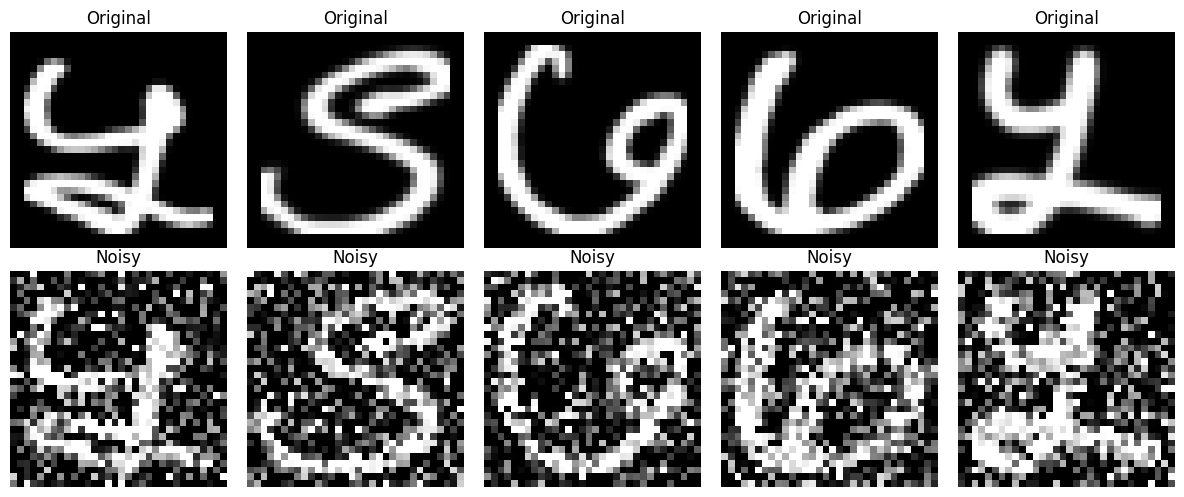

In [10]:
n = 5

plt.figure(figsize=(12, 5))

for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(32, 32), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(32, 32), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

#2. Build the Denoising Convolutional Autoencoder:

In [11]:
def build_encoder(input_shape=(32, 32, 1)):
    input_img = Input(shape=input_shape, name="input_image")

    x = Conv2D(32, (3, 3), activation="relu", padding="same", name="encoder_conv1")(input_img)
    x = MaxPooling2D((2, 2), padding="same", name="encoder_pool1")(x)

    x = Conv2D(64, (3, 3), activation="relu", padding="same", name="encoder_conv2")(x)
    x = MaxPooling2D((2, 2), padding="same", name="encoder_pool2")(x)

    x = Conv2D(128, (3, 3), activation="relu", padding="same", name="encoder_conv3")(x)
    encoded = MaxPooling2D((2, 2), padding="same", name="encoded_layer")(x)

    return input_img, encoded

In [12]:
def build_decoder(encoded_input):
    x = Conv2D(128, (3, 3), activation="relu", padding="same", name="decoder_conv1")(encoded_input)
    x = UpSampling2D((2, 2), name="decoder_upsample1")(x)

    x = Conv2D(64, (3, 3), activation="relu", padding="same", name="decoder_conv2")(x)
    x = UpSampling2D((2, 2), name="decoder_upsample2")(x)

    x = Conv2D(32, (3, 3), activation="relu", padding="same", name="decoder_conv3")(x)
    x = UpSampling2D((2, 2), name="decoder_upsample3")(x)

    decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same", name="decoded_output")(x)

    return decoded

In [13]:
def build_autoencoder():
    input_img, encoded_output = build_encoder(input_shape=(32, 32, 1))
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="devnagari_denoising_autoencoder")

    autoencoder.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy"
    )

    return autoencoder

autoencoder = build_autoencoder()
autoencoder.summary()

Model: "devnagari_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv1 (Conv2D)          │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool1 (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv2 (Conv2D)          │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_pool2 (MaxPooling2D)    │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv3 (Conv2D)          │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded_layer (MaxPooling2D)    │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv1 (Conv2D)          │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample1               │ (None, 8, 8, 128)      │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv2 (Conv2D)          │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample2               │ (None, 16, 16, 64)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_conv3 (Conv2D)          │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_upsample3               │ (None, 32, 32, 32)     │             0 │
│ (UpSampling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded_output (Conv2D)         │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

#3. Train the Denoising Autoencoder:

In [14]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 97s 870ms/step - loss: 0.3639 - val_loss: 0.2540
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 133s 794ms/step - loss: 0.2217 - val_loss: 0.2018
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 82s 767ms/step - loss: 0.1933 - val_loss: 0.1852
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 778ms/step - loss: 0.1805 - val_loss: 0.1757
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 85s 789ms/step - loss: 0.1723 - val_loss: 0.1704
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 83s 773ms/step - loss: 0.1684 - val_loss: 0.1695
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 84s 781ms/step - loss: 0.1637 - val_loss: 0.1685
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 82s 767ms/step - loss: 0.1611 - val_loss: 0.1621
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 143s 777ms/step - loss: 0.1583 - val_loss: 0.1588
Epoch 10/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 84s 778ms/step - loss: 0.1561 - val_loss: 0.1585


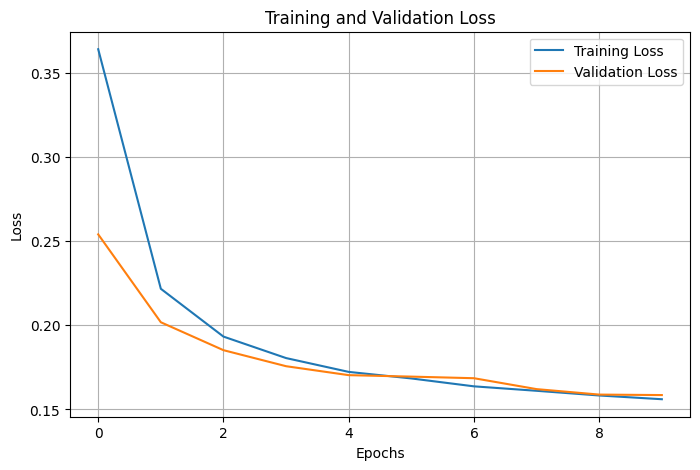

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

#4. Evaluate and Visualize the Results:

In [16]:
denoised_images = autoencoder.predict(x_test_noisy)

print("Denoised images shape:", denoised_images.shape)

94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step
Denoised images shape: (3000, 32, 32, 1)


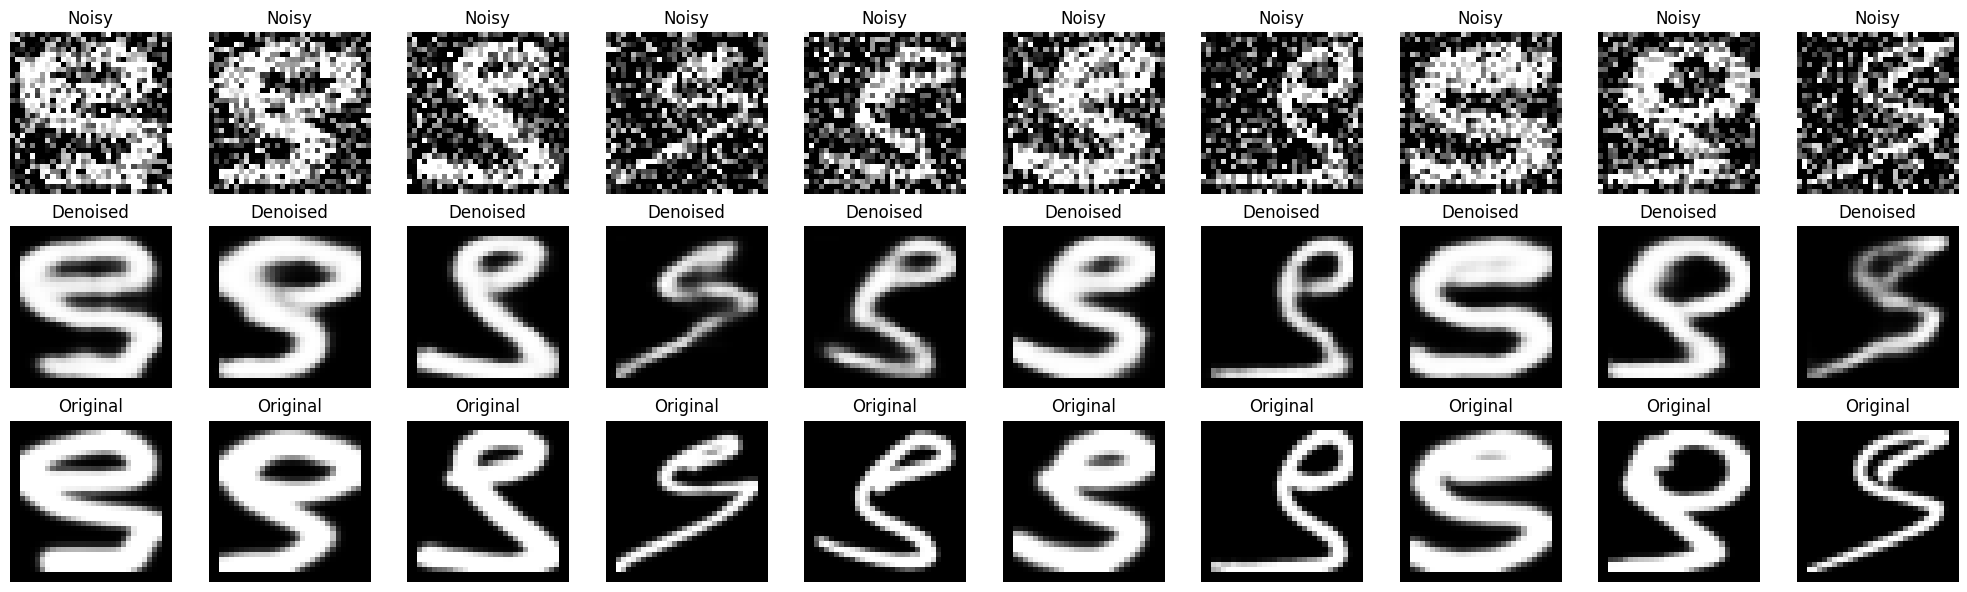

In [17]:
def plot_denoising_results(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(32, 32), cmap="gray")
        plt.title("Noisy")
        plt.axis("off")

        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(32, 32), cmap="gray")
        plt.title("Denoised")
        plt.axis("off")

        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(32, 32), cmap="gray")
        plt.title("Original")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

plot_denoising_results(x_test_noisy, denoised_images, x_test, n=10)

#5. Experiment and Fine - Tune the Model:

Testing noise factor: 0.2
94/94 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step


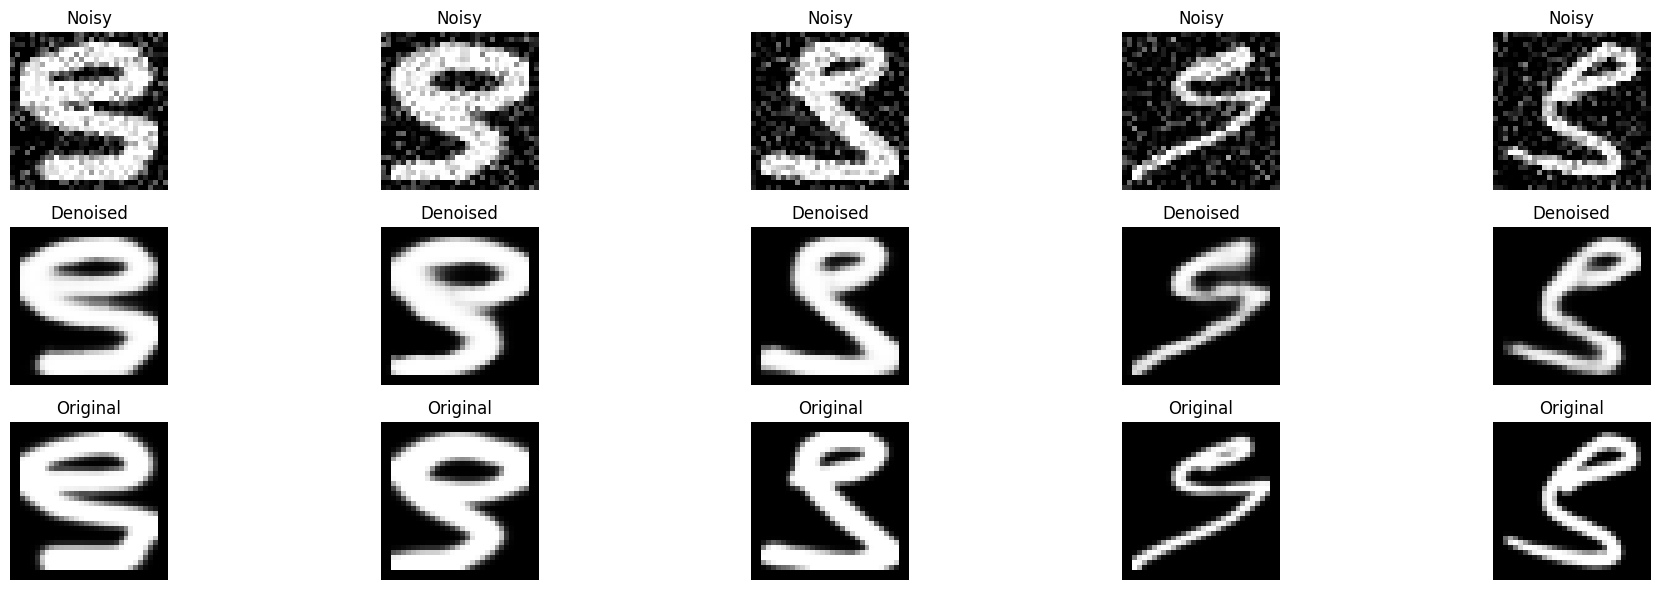

Testing noise factor: 0.3
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step


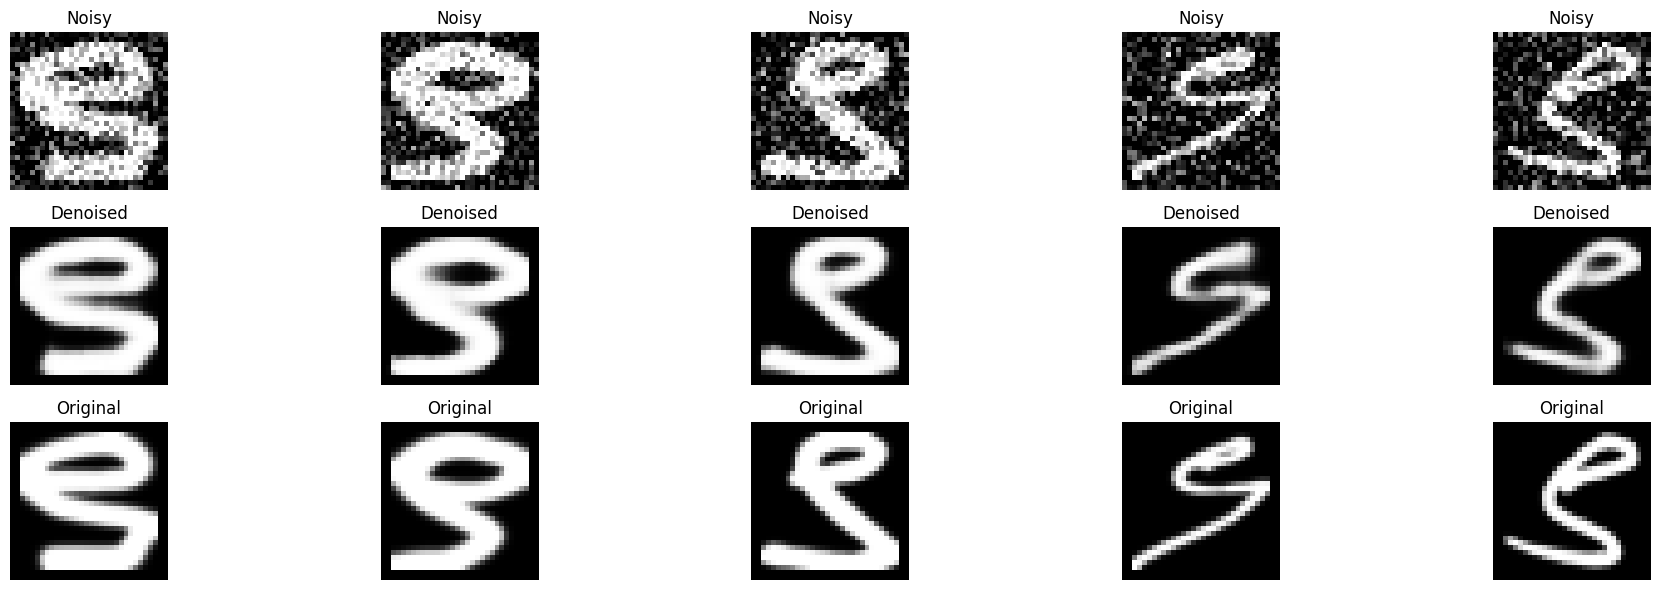

Testing noise factor: 0.5
94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step


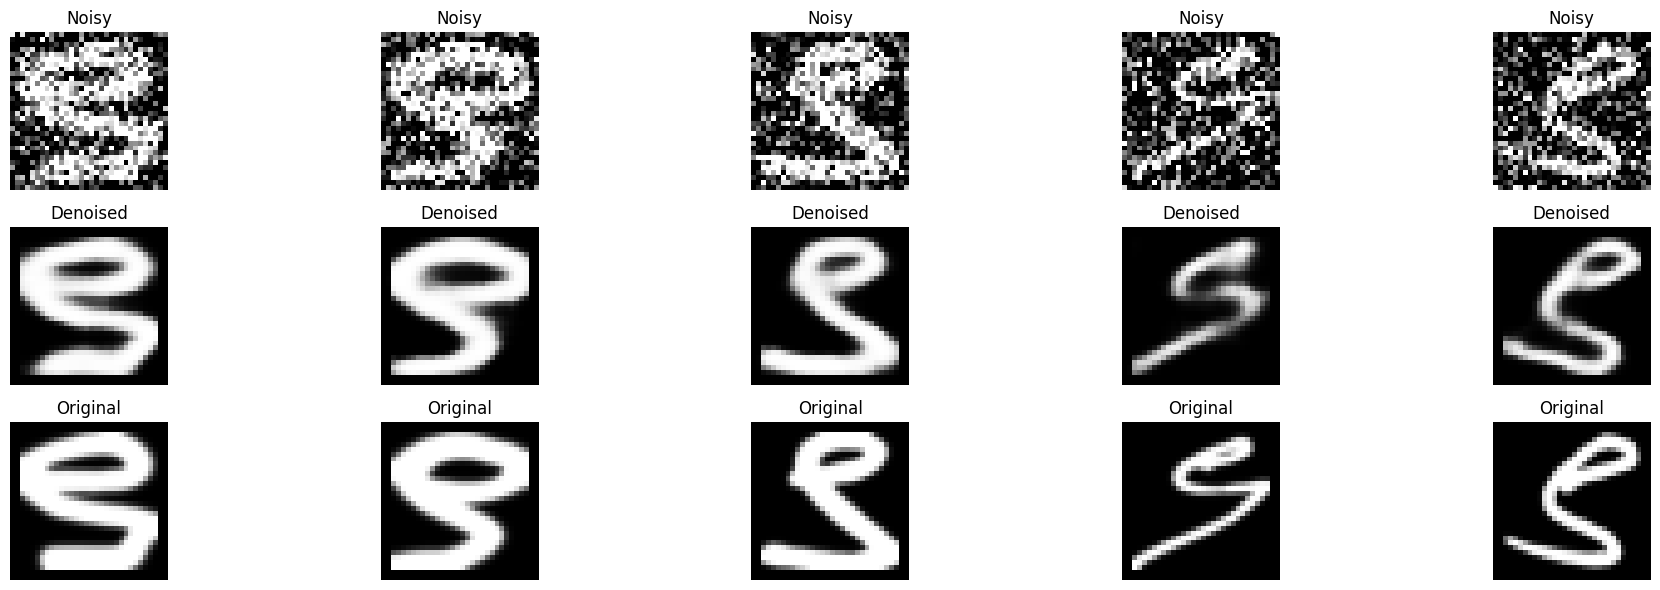

In [19]:
noise_levels = [0.2, 0.3, 0.5]

for noise_factor in noise_levels:
    print("Testing noise factor:", noise_factor)

    x_test_noisy_exp = x_test + noise_factor * np.random.normal(
        loc=0.0,
        scale=1.0,
        size=x_test.shape
    )

    x_test_noisy_exp = np.clip(x_test_noisy_exp, 0.0, 1.0)

    denoised_exp = autoencoder.predict(x_test_noisy_exp)

    plot_denoising_results(x_test_noisy_exp, denoised_exp, x_test, n=5)

In this experiment, different noise factors were tested to observe how noise level affects the performance of the denoising convolutional autoencoder. The tested noise factors were 0.2, 0.3 and 0.5.

When the noise factor was 0.2, the noisy images were only slightly distorted. The autoencoder was able to reconstruct the digits clearly and most of the digit shapes were close to the original clean images.

When the noise factor was 0.3, the input images contained more visible noise. The model was still able to recover the main digit structure, but the denoised images appeared slightly smoother and less sharp compared to the original images.

When the noise factor was 0.5, the input images had heavy noise. The reconstructed images were blurrier and some small details were harder to recover. However, the general shape of the digits was still visible.

Overall, the experiment shows that lower noise levels are easier for the autoencoder to remove, while higher noise levels make reconstruction more difficult. The model performed better when the noise factor was lower because less image information was corrupted.